In [1]:
# Get necessary libraries
try:
    import pandas as pd
    print("pandas available")
except ImportError:    
    print("Need to install pandas")
    import subprocess
    subprocess.run(["pip", "install", "pandas"], capture_output=True)
    import pandas as pd
    print("pandas installed")

try:
    from gradio_client import Client
    print("gradio_client available")
except ImportError:
    print("Need to install gradio_client")
    import subprocess
    subprocess.run(["pip", "install", "gradio_client"], capture_output=True)
    from gradio_client import Client
    print("gradio_client installed")

try:
    import numpy as np
    print("numpy available")
except ImportError:
    print("Need to install numpy")
    import subprocess
    subprocess.run(["pip", "install", "numpy"], capture_output=True)
    import numpy as np
    print("numpy installed")

try:
    from scipy import stats
    print("scipy available")
except ImportError:
    print("Need to install scipy")
    import subprocess
    subprocess.run(["pip", "install", "scipy"], capture_output=True)
    from scipy import stats
    print("scipy installed")

try:
    import matplotlib.pyplot as plt
    print("matplotlib available")
except ImportError:
    print("Need to install matplotlib")
    import subprocess
    subprocess.run(["pip", "install", "matplotlib"], capture_output=True)
    import matplotlib.pyplot as plt
    print("matplotlib installed")

pandas available


/home/tillman/miniconda3/envs/elegance/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


gradio_client available
numpy available
scipy available
matplotlib available


In [2]:
import scipy

In [3]:
# Source: Cetin et al., Journal of Chemical Information and Modeling 2022 (10.1021/acs.jcim.2c00507)
# Trimethoprim-resistance DHFR mutants with steady-state kinetic data.

mutant_data_jcim = {
    'mutant': ['WT', 'I5F', 'A26T', 'D27E', 'L28R', 'W30G', 'W30R', 'I94L', 'R98P', 'F153S'],
    'Km (μM)': [2.86, 7.68, 7.65, 56.4, 0.95, 9.49, 4.97, 14.87, 34.93, 11.32],
    'kcat (s⁻¹)': [5.36, 3.78, 3.70, 14.31, 1.13, 8.18, 8.62, 7.71, 2.82, 5.62],
}

wt_seq = "MISLIAALAVDRVIGMENAMPWNLPADLAWFKRNTLDKPVIMGRHTWESIGRPLPGRKNIILSSQPGTDDRVTWVKSVDEAIAACGDVPEIMVIGGGRVYEQFLPKAQKLYLTHIDAEVEGDTHFPDYEPDDWESVFSEFHDADAQNSHSYCFEILERR"

df_jcim = pd.DataFrame(mutant_data_jcim)
df_jcim

,mutant,Km (μM),kcat (s⁻¹)
0,WT,2.86,5.36
1,I5F,7.68,3.78
2,A26T,7.65,3.70
3,D27E,56.40,14.31
4,L28R,0.95,1.13
5,W30G,9.49,8.18
6,W30R,4.97,8.62
7,I94L,14.87,7.71
8,R98P,34.93,2.82
9,F153S,11.32,5.62


In [4]:
# Create mutant sequences
def make_mutant_sequence(wt_seq, mutation_str):
    """Create mutant sequence from WT and mutation string like 'M42F'"""
    seq = list(wt_seq)
    
    if mutation_str == "WT":
        return wt_seq
    
    wt_aa = mutation_str[0]
    pos = int(mutation_str[1:-1])  # 1-indexed
    new_aa = mutation_str[-1]

    # Verify WT amino acid
    if seq[pos-1] != wt_aa:
        print(f"WARNING: Expected {wt_aa} at position {pos}, found {seq[pos-1]}")
    seq[pos-1] = new_aa
    
    return ''.join(seq)

# Generate mutant sequences and FASTA
fasta_lines = []
for id in df_jcim['mutant']:
    seq = make_mutant_sequence(wt_seq, id)
    fasta_lines.append(f">{id}")
    fasta_lines.append(seq)

fasta_content = '\n'.join(fasta_lines)
print(fasta_content)
print(f"\nTotal sequences: {len(df_jcim)}")

# Write to file
with open('dhfr_mutants.fasta', 'w') as f:
    f.write(fasta_content)

>WT
MISLIAALAVDRVIGMENAMPWNLPADLAWFKRNTLDKPVIMGRHTWESIGRPLPGRKNIILSSQPGTDDRVTWVKSVDEAIAACGDVPEIMVIGGGRVYEQFLPKAQKLYLTHIDAEVEGDTHFPDYEPDDWESVFSEFHDADAQNSHSYCFEILERR
>I5F
MISLFAALAVDRVIGMENAMPWNLPADLAWFKRNTLDKPVIMGRHTWESIGRPLPGRKNIILSSQPGTDDRVTWVKSVDEAIAACGDVPEIMVIGGGRVYEQFLPKAQKLYLTHIDAEVEGDTHFPDYEPDDWESVFSEFHDADAQNSHSYCFEILERR
>A26T
MISLIAALAVDRVIGMENAMPWNLPTDLAWFKRNTLDKPVIMGRHTWESIGRPLPGRKNIILSSQPGTDDRVTWVKSVDEAIAACGDVPEIMVIGGGRVYEQFLPKAQKLYLTHIDAEVEGDTHFPDYEPDDWESVFSEFHDADAQNSHSYCFEILERR
>D27E
MISLIAALAVDRVIGMENAMPWNLPAELAWFKRNTLDKPVIMGRHTWESIGRPLPGRKNIILSSQPGTDDRVTWVKSVDEAIAACGDVPEIMVIGGGRVYEQFLPKAQKLYLTHIDAEVEGDTHFPDYEPDDWESVFSEFHDADAQNSHSYCFEILERR
>L28R
MISLIAALAVDRVIGMENAMPWNLPADRAWFKRNTLDKPVIMGRHTWESIGRPLPGRKNIILSSQPGTDDRVTWVKSVDEAIAACGDVPEIMVIGGGRVYEQFLPKAQKLYLTHIDAEVEGDTHFPDYEPDDWESVFSEFHDADAQNSHSYCFEILERR
>W30G
MISLIAALAVDRVIGMENAMPWNLPADLAGFKRNTLDKPVIMGRHTWESIGRPLPGRKNIILSSQPGTDDRVTWVKSVDEAIAACGDVPEIMVIGGGRVYEQFLPKAQKLYLTHIDAEVEGDTHFPDYEPDDWESVFSEFHDADAQNSHSYCFEILERR
>W30R
M

In [5]:
# Try to connect to Flexpert webserver
from gradio_client import Client

try:
    client = Client("Honzus24/flexpert")
except Exception as e:
    print(f"Error occurred while connecting to Flexpert: {e}")

# Check what the API looks like
print(client.view_api())

Loaded as API: https://honzus24-flexpert.hf.space
Client.predict() Usage Info
---------------------------
Named API endpoints: 7

 - predict(api_name="/switch_component_view") -> (paste_protein_sequences_fasta_format, select_one_or_more_pdb_files_or_a_fasta_file_containing_one_or_more_proteins)
    Parameters:
     - None
    Returns:
     - [Textbox] paste_protein_sequences_fasta_format: str 
     - [File] select_one_or_more_pdb_files_or_a_fasta_file_containing_one_or_more_proteins: list[filepath] 

 - predict(api_name="/switch_component_view_1") -> (paste_protein_sequences_fasta_format, select_one_or_more_pdb_files_or_a_fasta_file_containing_one_or_more_proteins)
    Parameters:
     - None
    Returns:
     - [Textbox] paste_protein_sequences_fasta_format: str 
     - [File] select_one_or_more_pdb_files_or_a_fasta_file_containing_one_or_more_proteins: list[filepath] 

 - predict(api_name="/clear_outputs") -> (output_message, protein_structure, value_22)
    Parameters:
     - None
 

In [6]:
# Call Flexpert-Seq via the API
result = client.predict(
    input_seq=fasta_content,
    input_file=[],  # No file, using text input
    use_gpu=False,  # Use CPU as recommended
    api_name="/handle_seq_prediction"
)
print(type(result))
print(result)
output_files = result[0]

<class 'tuple'>
(['/tmp/gradio/c6f3decdbd7f1f7cd7eb03980278c772b432acf6b55704fdc3f61bc3b9a2093b/WT_20260422_135114-seq.txt', '/tmp/gradio/51db0a6b99ccd6810f85aa3f2307187fa37224c90e200699b733fa079b32faa5/I5F_20260422_135114-seq.txt', '/tmp/gradio/4e9c0ea589c041da22d30ee8182c9ac0818f7891e6521f019d42ab88654f2b38/A26T_20260422_135114-seq.txt', '/tmp/gradio/6cf30d4d5cb13fd6c935d804a3715c241b810d1e9e184aed5fc0fb51b56d8bb4/D27E_20260422_135114-seq.txt', '/tmp/gradio/be2ecc846108643be41149a95e6f4a7004c3bc1ad51c5eeaab98f23d1fe0e7b2/L28R_20260422_135114-seq.txt', '/tmp/gradio/e31c3b575d66b91d7f1a9eba7f974bf02d8b28faabd43f2cb05ead3136570827/W30G_20260422_135114-seq.txt', '/tmp/gradio/3a047ee0338e43ba7ca446dd8bb36794d744b5787f089772fd10a96c27b3a726/W30R_20260422_135114-seq.txt', '/tmp/gradio/de04dbe6efd5c8932349eff56cf3b04cb170eef26f1f8a4057715f6643c2076f/I94L_20260422_135114-seq.txt', '/tmp/gradio/494bea256b04d19229538b66ea34752cf45ede160c705dd44b94016dd9d59085/R98P_20260422_135114-seq.txt', '/tm

In [7]:
# Visualize the predictions for the Wild Type (WT) sequence
with open(output_files[0], 'r') as f:
    content = f.read()
print(content)

Residue Number	Residue ID	Flexibility
0         	M                   	0.0609    
1         	I                   	0.0271    
2         	S                   	0.0195    
3         	L                   	0.0145    
4         	I                   	0.0177    
5         	A                   	0.0188    
6         	A                   	0.0189    
7         	L                   	0.0182    
8         	A                   	0.0336    
9         	V                   	0.0581    
10        	D                   	0.0678    
11        	R                   	0.0499    
12        	V                   	0.0397    
13        	I                   	0.0438    
14        	G                   	0.0671    
15        	M                   	0.0929    
16        	E                   	0.127     
17        	N                   	0.1253    
18        	A                   	0.0948    
19        	M                   	0.0817    
20        	P                   	0.0893    
21        	W                   	0.0818    
22        	N    

In [8]:
import numpy as np
import os

flexibility_data = {}

for fpath in output_files:
    if fpath.endswith('.txt'):
        # Extract mutant name from filename (e.g., "WT_predictions.txt" -> "WT")
        name = os.path.basename(fpath).split('_')[0]
        with open(fpath, 'r') as f:
            lines = f.readlines()
        
        # Skip header
        values = []
        residues = []
        for line in lines[1:]:
            parts = line.strip().split('\t')
            if len(parts) >= 3:
                residues.append(parts[1].strip())
                values.append(float(parts[2].strip()))
        
        flexibility_data[name] = np.array(values)
        print(f"{name}: mean RMSF = {np.mean(values):.4f} nm")

print(f"\nTotal predictions: {len(flexibility_data)}")

WT: mean RMSF = 0.0692 nm
I5F: mean RMSF = 0.0700 nm
A26T: mean RMSF = 0.0696 nm
D27E: mean RMSF = 0.0704 nm
L28R: mean RMSF = 0.0668 nm
W30G: mean RMSF = 0.0699 nm
W30R: mean RMSF = 0.0697 nm
I94L: mean RMSF = 0.0709 nm
R98P: mean RMSF = 0.0675 nm
F153S: mean RMSF = 0.0709 nm

Total predictions: 10


In [9]:
# Lets take a look at regional flexibility.
regions = {
    'Met20 RSMF': (9, 24),    # Critical for closed-to-occluded transition
    'CD RSMF': (64, 71),      # Contains residues important for substrate binding
    'FG RSMF': (117, 131),    # Contains G121
    'GH RSMF': (142, 150),    # C-terminal region
}

# Write flexibility metrics directly into df_jcim
df_jcim = df_jcim.copy()

for region_name, (start, end) in regions.items():
    df_jcim[f"{region_name}"] = df_jcim['mutant'].map(
        lambda m: np.mean(flexibility_data[m][start:end])
    )

df_jcim['Mean RSMF'] = df_jcim['mutant'].map(
    lambda m: np.mean(flexibility_data[m])
)

# order by kcat
df_jcim = df_jcim.sort_values(by='kcat (s⁻¹)', ascending=False)

df_jcim

,mutant,Km (μM),kcat (s⁻¹),Met20 RSMF,CD RSMF,FG RSMF,GH RSMF,Mean RSMF
3,D27E,56.40,14.31,0.083240,0.093357,0.078079,0.175800,0.070416
6,W30R,4.97,8.62,0.081100,0.090429,0.076279,0.182312,0.069695
5,W30G,9.49,8.18,0.080287,0.089714,0.076657,0.181037,0.069855
7,I94L,14.87,7.71,0.082107,0.093257,0.078543,0.177725,0.070909
9,F153S,11.32,5.62,0.082187,0.093714,0.077671,0.185037,0.070949
0,WT,2.86,5.36,0.081100,0.091729,0.077429,0.176463,0.069239
1,I5F,7.68,3.78,0.082073,0.092643,0.078257,0.178563,0.069998
2,A26T,7.65,3.70,0.081247,0.092100,0.077500,0.177762,0.069596
8,R98P,34.93,2.82,0.079387,0.089857,0.075671,0.173387,0.067494
4,L28R,0.95,1.13,0.075267,0.088686,0.074650,0.170725,0.066796


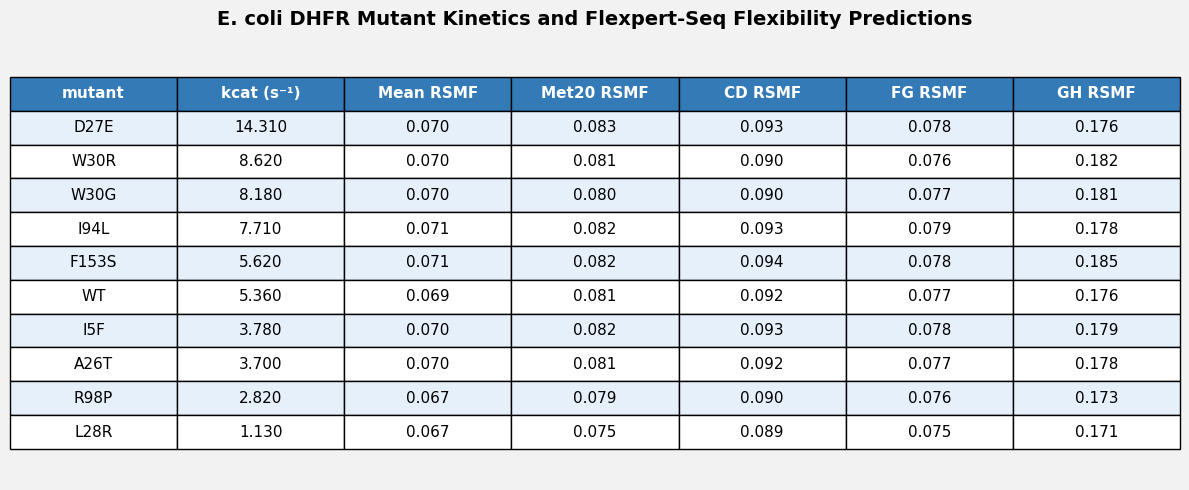

In [10]:
df_table = df_jcim[['mutant', 'kcat (s⁻¹)', 'Mean RSMF', 'Met20 RSMF', 'CD RSMF', 'FG RSMF', 'GH RSMF']]
numeric_cols = df_table.select_dtypes(include=['float', 'int']).columns

for col in numeric_cols:
    df_table[col] = df_table[col].map('{:.3f}'.format)


fig, ax = plt.subplots(figsize=(12, 5))
ax.axis("off")
ax.axis("tight")

# Convert everything to strings for standardizing the plot text
table = ax.table(
    cellText=df_table.astype(str).values, colLabels=df_table.columns, cellLoc="center", loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)

header_bg = "#337ab7"
fig.patch.set_facecolor("#f2f2f2")
row_colors = ["#ffffff", "#e6f0fa"]

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("black")
    if row == 0:
        cell.set_facecolor(header_bg)
        cell.set_text_props(weight="bold", color="white")
    else:
        cell.set_facecolor(row_colors[row % 2])

plt.title(
    "E. coli DHFR Mutant Kinetics and Flexpert-Seq Flexibility Predictions",
    fontweight="bold",
    size=14,
    pad=15,
)

plt.tight_layout()

In [11]:
from scipy import stats

# Calculate correlations with log transformed kcat and kcat/Km
# for better correlation analysis
df_corr = df_jcim.copy()
df_corr['log_kcat'] = np.log10(df_corr['kcat (s⁻¹)'])
df_corr['kcat_over_Km'] = df_corr['kcat (s⁻¹)'] / df_corr['Km (μM)']
df_corr['log_kcat_Km'] = np.log10(df_corr['kcat_over_Km'])


print("\n=== Correlations with log(kcat) ===")
for region in ['Mean RSMF', 'Met20 RSMF', 'FG RSMF', 'CD RSMF', 'GH RSMF']:
    r_s, p_s = stats.spearmanr(df_corr[region], df_corr['log_kcat'])
    r_p, p_p = stats.pearsonr(df_corr[region], df_corr['log_kcat'])
    print(f"  {region:20s}: Spearman rho={r_s:.3f} (p={p_s:.3f}), Pearson r={r_p:.3f} (p={p_p:.3f})")

print("\n=== Correlations with catalytic efficiency log(kcat/Km) ===")
for region in ['Mean RSMF', 'Met20 RSMF', 'FG RSMF', 'CD RSMF', 'GH RSMF']:
    r_s, p_s = stats.spearmanr(df_corr[region], df_corr['log_kcat_Km'])
    r_p, p_p = stats.pearsonr(df_corr[region], df_corr['log_kcat_Km'])
    print(f"  {region:20s}: Spearman rho={r_s:.3f} (p={p_s:.3f}), Pearson r={r_p:.3f} (p={p_p:.3f})")


=== Correlations with log(kcat) ===
  Mean RSMF           : Spearman rho=0.648 (p=0.043), Pearson r=0.802 (p=0.005)
  Met20 RSMF          : Spearman rho=0.527 (p=0.117), Pearson r=0.827 (p=0.003)
  FG RSMF             : Spearman rho=0.394 (p=0.260), Pearson r=0.641 (p=0.046)
  CD RSMF             : Spearman rho=0.406 (p=0.244), Pearson r=0.543 (p=0.105)
  GH RSMF             : Spearman rho=0.467 (p=0.174), Pearson r=0.576 (p=0.081)

=== Correlations with catalytic efficiency log(kcat/Km) ===
  Mean RSMF           : Spearman rho=-0.188 (p=0.603), Pearson r=0.071 (p=0.845)
  Met20 RSMF          : Spearman rho=-0.321 (p=0.365), Pearson r=-0.180 (p=0.618)
  FG RSMF             : Spearman rho=-0.273 (p=0.446), Pearson r=-0.091 (p=0.802)
  CD RSMF             : Spearman rho=-0.358 (p=0.310), Pearson r=-0.186 (p=0.608)
  GH RSMF             : Spearman rho=0.200 (p=0.580), Pearson r=0.245 (p=0.495)


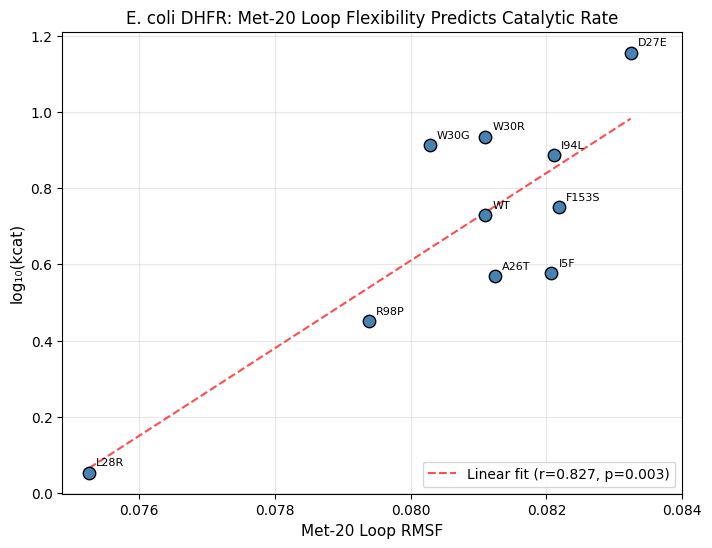

In [12]:
# Figure: Correlation plot for Met-20 loop RMSF with log(kcat)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Plot 1: Met-20 loop RMSF vs kcat
ax.scatter(df_corr['Met20 RSMF'], df_corr['log_kcat'], 
           s=80, c='steelblue', edgecolors='black', zorder=5)

for _, row in df_corr.iterrows():
    ax.annotate(row['mutant'], (row['Met20 RSMF'], row['log_kcat']),
                textcoords="offset points", xytext=(5,5), fontsize=8)

# Add regression line
slope, intercept, r_val, p_val, se = stats.linregress(df_corr['Met20 RSMF'], 
                                                        df_corr['log_kcat'])
x_line = np.linspace(df_corr['Met20 RSMF'].min(), 
                       df_corr['Met20 RSMF'].max(), 100)

ax.plot(x_line, slope * x_line + intercept, 'r--', alpha=0.7, label=f'Linear fit (r={r_val:.3f}, p={p_val:.3f})')
ax.set_xlim(right=0.084)
ax.set_xlabel('Met-20 Loop RMSF', fontsize=11)
ax.set_ylabel('log₁₀(kcat)', fontsize=11)
ax.set_title('E. coli DHFR: Met-20 Loop Flexibility Predicts Catalytic Rate')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
plt.show()

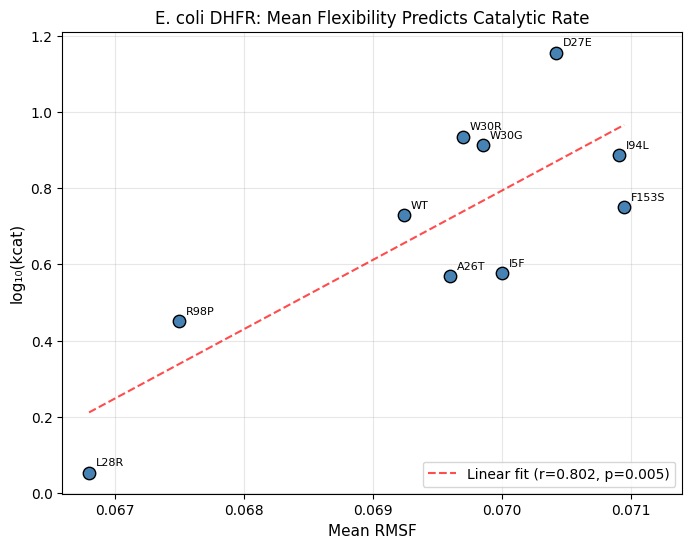

In [13]:
# Figure:  Correlation plot for Mean RMSF with log(kcat)
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.scatter(df_corr['Mean RSMF'], df_corr['log_kcat'], 
           s=80, c='steelblue', edgecolors='black', zorder=5)

for _, row in df_corr.iterrows():
    ax.annotate(row['mutant'], (row['Mean RSMF'], row['log_kcat']),
                textcoords="offset points", xytext=(5,5), fontsize=8)

# Add regression line
slope, intercept, r_val, p_val, se = stats.linregress(df_corr['Mean RSMF'], 
                                                        df_corr['log_kcat'])
x_line = np.linspace(df_corr['Mean RSMF'].min(), 
                       df_corr['Mean RSMF'].max(), 100)

ax.plot(x_line, slope * x_line + intercept, 'r--', alpha=0.7, label=f'Linear fit (r={r_val:.3f}, p={p_val:.3f})')
ax.set_xlim(right=0.0714)
ax.set_xlabel('Mean RMSF', fontsize=11)
ax.set_ylabel('log₁₀(kcat)', fontsize=11)
ax.set_title('E. coli DHFR: Mean Flexibility Predicts Catalytic Rate')
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
plt.show()

In [14]:
# Per-residue flexibility changes relative to WT
# Which positions show the largest flexibility changes across mutants?

wt_rmsf = flexibility_data['WT']
delta_rmsf_matrix = {}

for name in flexibility_data:
    if name != 'WT':
        delta_rmsf_matrix[name] = flexibility_data[name] - wt_rmsf

delta_df = pd.DataFrame(delta_rmsf_matrix, index=range(1, 160))

# Find positions with highest variance in flexibility across mutants
# These are positions whose flexibility is most sensitive to mutations elsewhere
position_variance = delta_df.var(axis=1)
position_max_delta = delta_df.abs().max(axis=1)

# Top positions most affected
top_variable = position_variance.nlargest(20)
print("=== Top 20 positions with highest flexibility variance across mutants ===")
print("(These positions are most sensitive to mutations elsewhere)")
for pos, var in top_variable.items():
    region = ""
    if 9 <= pos <= 24: region = "(Met-20 loop)"
    elif 64 <= pos <= 71: region = "(CD loop)"
    elif 117 <= pos <= 131: region = "(FG loop)"
    elif 142 <= pos <= 150: region = "(GH loop)"
    print(f"  Residue {pos:3d} ({wt_seq[pos-1]}): variance = {var:.2e}, "
          f"max |Δ| = {position_max_delta[pos]:.4f} nm {region}")

=== Top 20 positions with highest flexibility variance across mutants ===
(These positions are most sensitive to mutations elsewhere)
  Residue  29 (A): variance = 8.82e-05, max |Δ| = 0.0247 nm 
  Residue  30 (W): variance = 7.55e-05, max |Δ| = 0.0206 nm 
  Residue 147 (N): variance = 7.40e-05, max |Δ| = 0.0215 nm (GH loop)
  Residue 148 (S): variance = 4.64e-05, max |Δ| = 0.0186 nm (GH loop)
  Residue  31 (F): variance = 2.92e-05, max |Δ| = 0.0113 nm 
  Residue 144 (D): variance = 2.73e-05, max |Δ| = 0.0086 nm (GH loop)
  Residue  33 (R): variance = 2.69e-05, max |Δ| = 0.0102 nm 
  Residue 146 (Q): variance = 2.56e-05, max |Δ| = 0.0085 nm (GH loop)
  Residue  23 (N): variance = 2.48e-05, max |Δ| = 0.0107 nm (Met-20 loop)
  Residue 145 (A): variance = 2.23e-05, max |Δ| = 0.0082 nm (GH loop)
  Residue   5 (I): variance = 2.11e-05, max |Δ| = 0.0136 nm 
  Residue  21 (P): variance = 1.85e-05, max |Δ| = 0.0110 nm (Met-20 loop)
  Residue  26 (A): variance = 1.74e-05, max |Δ| = 0.0095 nm 
  

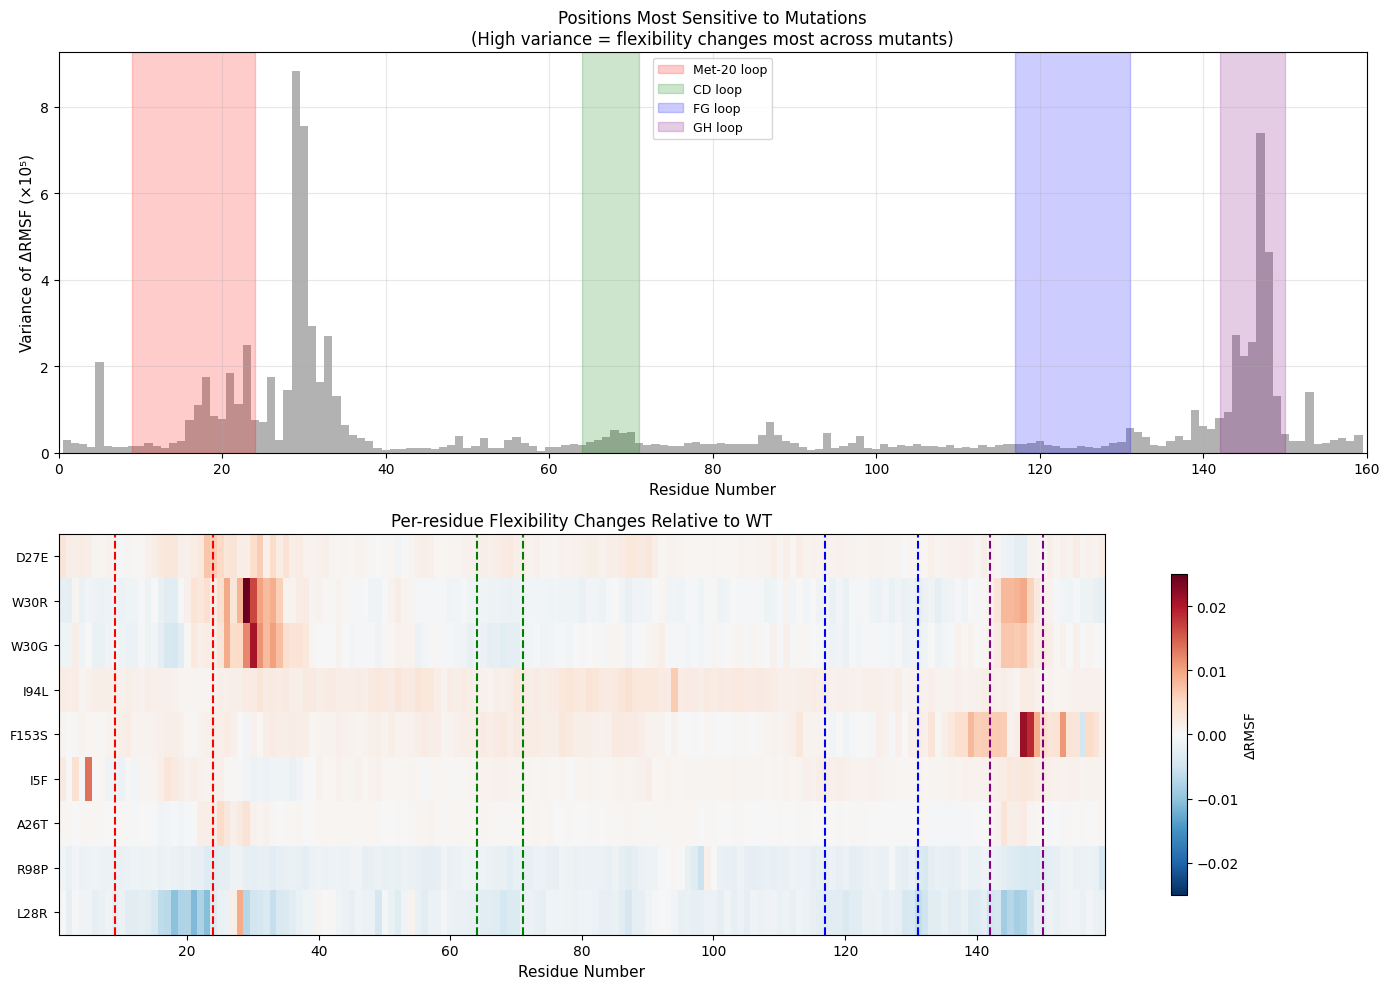

In [15]:
# The positions most sensitive to mutations are in:
# 1. Residues 29-33 (near the Met-20 loop, substrate binding pocket edge)
# 2. GH loop (residues 144-149) - known to be important for product release
# 3. Met-20 loop (residues 16-23) - directly involved in catalysis
# 5. Position 5 - near active site

# Create a position importance map
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Variance of flexibility changes across mutants
ax = axes[0]
ax.bar(range(1, 160), position_variance.values * 1e5, color='gray', alpha=0.6, width=1)
# Highlight key regions
for start, end, color, label in [(9, 24, 'red', 'Met-20 loop'),
                                   (64, 71, 'green', 'CD loop'),
                                   (117, 131, 'blue', 'FG loop'),
                                   (142, 150, 'purple', 'GH loop')]:
    ax.axvspan(start, end, alpha=0.2, color=color, label=label)
ax.set_xlabel('Residue Number', fontsize=11)
ax.set_ylabel('Variance of ΔRMSF (×10⁵)', fontsize=11)
ax.set_title('Positions Most Sensitive to Mutations\n(High variance = flexibility changes most across mutants)', fontsize=12)
ax.legend(fontsize=9)
ax.set_xlim(0, 160)
ax.grid(True, alpha=0.3)

# Plot 2: Heatmap of flexibility changes per mutant
import matplotlib.colors as mcolors

ax = axes[1]

# Create matrix for heatmap
sorted_mutants = df_jcim[df_jcim['mutant'] != 'WT'].sort_values(by='kcat (s⁻¹)', ascending=False)['mutant']
matrix = np.array([delta_rmsf_matrix[n] for n in sorted_mutants])  # Convert to Angstrom

im = ax.imshow(matrix, aspect='auto', cmap='RdBu_r', 
               extent=[0.5, 159.5, len(sorted_mutants)-0.5, -0.5],
               vmin=-0.025, vmax=0.025)
ax.set_yticks(range(len(sorted_mutants)))
ax.set_yticklabels(sorted_mutants, fontsize=9)
ax.set_xlabel('Residue Number', fontsize=11)
ax.set_title('Per-residue Flexibility Changes Relative to WT', fontsize=12)
plt.colorbar(im, ax=ax, label='ΔRMSF', shrink=0.8)

# Add region labels
for start, end, color, label in [(9, 24, 'red', 'Met-20 loop'),
                                   (64, 71, 'green', 'CD loop'),
                                   (117, 131, 'blue', 'FG loop'),
                                   (142, 150, 'purple', 'GH loop')]:
    ax.axvline(start, color=color, ls='--', lw=1.5)
    ax.axvline(end, color=color, ls='--', lw=1.5)

plt.tight_layout()
plt.show()